In [3]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import re
import os

RESULTS_DIR = os.path.expanduser(
    "~/Documents/PTTEP/permeation_barrier_analysis/ShieldRunsAnalysis/results"
)

def parse_ufloat_nominal(value):
    """Parse '(5.9+/-1.2)e+12' -> 5.9e12 as a plain float."""
    match = re.match(r"\(?([0-9.\-eE]+)\+/-[0-9.\-eE]+\)?(?:e([+\-]?[0-9]+))?", value.strip())
    if match:
        val = float(match.group(1))
        exp = int(match.group(2)) if match.group(2) else 0
        return val * 10**exp
    return float(value)

def load_shield_csv(filepath):
    """Load a SHIELD CSV and return (1/T array, permeability array)."""
    inv_T, perm = [], []
    with open(filepath) as f:
        for row in csv.DictReader(f):
            inv_T.append(1.0 / float(row["Temperature (K)"]))
            perm.append(parse_ufloat_nominal(row["Permeability"]))
    return np.array(inv_T), np.array(perm)

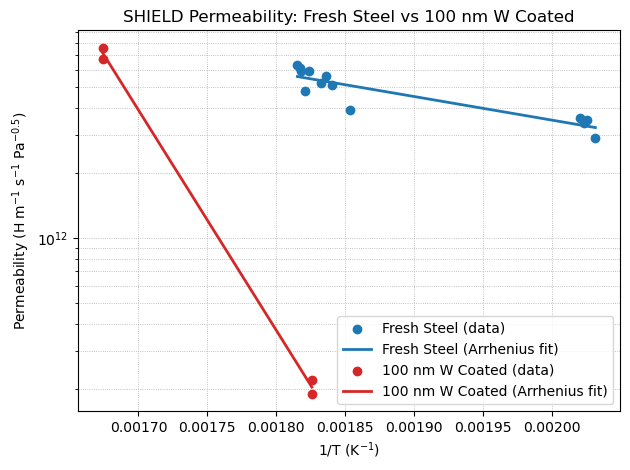

In [4]:
fresh_csv = os.path.join(RESULTS_DIR, "fresh_steel_diffusivities.csv")
coated_csv = os.path.join(RESULTS_DIR, "100nm_W_coated_carbon_steel_diffusivities.csv")

fresh_x, fresh_y = load_shield_csv(fresh_csv)
coated_x, coated_y = load_shield_csv(coated_csv)

fig, ax = plt.subplots()

for x, y, color, label in [
    (fresh_x, fresh_y, "tab:blue", "Fresh Steel"),
    (coated_x, coated_y, "tab:red", "100 nm W Coated"),
]:
    ax.scatter(x, y, color=color, zorder=3, label=f"{label} (data)")
    m, b = np.polyfit(x, np.log(y), 1)
    xs = np.linspace(x.min(), x.max(), 200)
    ax.plot(xs, np.exp(m * xs + b), color=color, linewidth=2, label=f"{label} (Arrhenius fit)")

ax.set_yscale("log")
ax.set_xlabel("1/T (K$^{-1}$)")
ax.set_ylabel("Permeability (H m$^{-1}$ s$^{-1}$ Pa$^{-0.5}$)")
ax.set_title("SHIELD Permeability: Fresh Steel vs 100 nm W Coated")
ax.grid(True, which="both", linestyle=":", linewidth=0.6)
ax.legend()
fig.tight_layout()
plt.show()